In [103]:
# ── Detail-Level Fed Figure A3 Replication (64 categories) ───────────────────
# Uses the 402-commodity detail IO tables + detail PCE Bridge to get ~64
# core goods categories instead of 27.  Matches the Fed's ~59 categories.

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import requests

import config
import pipeline_detail
importlib.reload(config)
importlib.reload(pipeline_detail)

# ── Run detail pipeline steps 1-6 (X-axis: predicted tariff effects) ────────
import_shares = pipeline_detail.detail_step1_import_shares(
    config.DETAIL_SUPPLY_FILE, config.DETAIL_IO_YEAR)
commodities, L = pipeline_detail.detail_step2_3_leontief(
    config.DETAIL_CXC_TR_FILE, config.DETAIL_IO_YEAR)
m_vec, m_total = pipeline_detail.detail_step4_total_import_content(
    import_shares, commodities, L)
delta_tariff_df = pipeline_detail.detail_step5_delta_tariff(
    config.IMPORTS_FILE, config.TARIFF_BASELINE_YEAR,
    config.TARIFF_CURRENT_MONTH, config.DETAIL_CONCORDANCE_FILE)
pce_bridge = pipeline_detail.load_detail_pce_bridge(
    config.DETAIL_PCE_BRIDGE_FILE, config.DETAIL_IO_YEAR)
detail_pce_effect = pipeline_detail.detail_step6_pce_effect(
    commodities, m_vec, L, delta_tariff_df, pce_bridge,
    config.MARKUP_ASSUMPTION)

# Filter to core goods detail categories
core = detail_pce_effect[
    detail_pce_effect['PCE_category'].isin(config.DETAIL_CORE_GOODS_CATEGORIES)
].copy()
core['pce_share'] = core['purchasers_value_total'] / core['purchasers_value_total'].sum()
print(f'Detail pipeline complete - {len(core)} core goods categories')
print(f'Weighted avg predicted effect: '
      f'{(core["predicted_effect"] * core["pce_share"]).sum():.2%}')

Detail Leontief: 402 commodities, diagonal range [1.000, 1.745]
Detail concordance: 374/388 NAICS6 codes mapped to BEA detail commodities
  Out of scope (services/unmapped): 14 codes
  BEA detail commodities covered: 235

Import value coverage: 84.4% of total import value mapped to BEA detail commodities

Import value coverage: 85.3% of total import value mapped to BEA detail commodities
Detail pipeline complete - 64 core goods categories
Weighted avg predicted effect: 2.17%


In [104]:
# ── Fetch U20404 monthly price indexes at detail level ───────────────────────
# Match on LineNumber (int) to avoid string-matching issues
# Fetch wide year range: 2014-2026 (need 2014-2019 for baseline, 2023-2026 for Fed window)

year_str = ','.join(str(y) for y in range(2014, 2027))
print(f'Fetching U20404 for years: {year_str}')

r = requests.get(
    'https://apps.bea.gov/api/data'
    f'?UserID={config.BEA_KEY}'
    '&method=GetData'
    '&DataSetName=NIUnderlyingDetail'
    '&TableName=U20404'
    '&Frequency=M'
    f'&Year={year_str}'
    '&ResultFormat=json'
)
r.raise_for_status()
pce_monthly = pd.DataFrame(r.json()['BEAAPI']['Results']['Data'])
pce_monthly['DataValue'] = pd.to_numeric(pce_monthly['DataValue'], errors='coerce')
pce_monthly['TimePeriod'] = pce_monthly['TimePeriod'].str.replace('M', '-', regex=False)
pce_monthly['LineNumber'] = pd.to_numeric(pce_monthly['LineNumber'], errors='coerce').astype('Int64')

# Build reverse map: LineNumber -> PCE category name
line_to_cat = {v: k for k, v in config.DETAIL_NIPA_LINE_NUMBERS.items()}
target_lines = set(config.DETAIL_NIPA_LINE_NUMBERS.values())

# Filter to our 64 detail core goods categories
pce_detail = pce_monthly[pce_monthly['LineNumber'].isin(target_lines)].copy()
pce_detail['PCE_category'] = pce_detail['LineNumber'].map(line_to_cat)

# Pivot to wide: rows = category, columns = month
_price_wide = pce_detail.pivot(
    index='PCE_category', columns='TimePeriod', values='DataValue'
)

matched = len(_price_wide)
print(f'Matched {matched} of {len(target_lines)} detail categories in U20404')
print(f'Date range: {sorted(_price_wide.columns)[0]} - {sorted(_price_wide.columns)[-1]}')
if matched < len(target_lines):
    missing = set(config.DETAIL_CORE_GOODS_CATEGORIES) - set(_price_wide.index)
    print(f'Missing: {missing}')

Fetching U20404 for years: 2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Matched 64 of 64 detail categories in U20404
Date range: 2014-01 - 2026-02


In [105]:
# ── Excess inflation: Fed Figure A3 definition ───────────────────────────────
# Baseline = avg monthly inflation Jan-Dec 2024, scaled to 13 months
# Current  = P(2026-02) / P(2025-01) - 1   (Jan 2025 -> Feb 2026)
# Excess   = current - baseline_scaled

months_2024 = [f'2024-{m:02d}' for m in range(1, 13)]
months_2024_prev = ['2023-12'] + [f'2024-{m:02d}' for m in range(1, 12)]

monthly_rates = pd.DataFrame(index=_price_wide.index)
for cur, prev in zip(months_2024, months_2024_prev):
    if cur in _price_wide.columns and prev in _price_wide.columns:
        monthly_rates[cur] = _price_wide[cur] / _price_wide[prev] - 1

avg_monthly_rate = monthly_rates.mean(axis=1)

N_MONTHS = 13
baseline_trend = (1 + avg_monthly_rate)**N_MONTHS - 1
current_inflation = _price_wide['2026-02'] / _price_wide['2025-01'] - 1
excess_inflation = current_inflation - baseline_trend

print(f'Computed excess inflation for {len(excess_inflation)} categories')
print(f'Median excess inflation: {excess_inflation.median():.2%}')
print(f'Range: [{excess_inflation.min():.2%}, {excess_inflation.max():.2%}]')

Computed excess inflation for 64 categories
Median excess inflation: 1.98%
Range: [-24.32%, 19.48%]


In [106]:
# ── Merge predicted tariff effect (X) with excess inflation (Y) ──────────────

inflation_df = pd.DataFrame({
    'current_inflation': current_inflation,
    'baseline_trend': baseline_trend,
    'excess_inflation': excess_inflation,
}).reset_index().rename(columns={'index': 'PCE_category'})

results = core[['PCE_category', 'predicted_effect', 'pce_share',
                'purchasers_value_total']].copy()
results = results.merge(inflation_df, on='PCE_category', how='inner')

results['predicted_contrib_pp'] = results['predicted_effect'] * results['pce_share'] * 100
results['excess_contrib_pp'] = results['excess_inflation'] * results['pce_share'] * 100

print(f'Categories with both X and Y: {len(results)}')
print(f'Total predicted contribution: {results["predicted_contrib_pp"].sum():.2f} pp')
print(f'Total excess contribution:   {results["excess_contrib_pp"].sum():.2f} pp')

Categories with both X and Y: 64
Total predicted contribution: 2.17 pp
Total excess contribution:   2.60 pp


## Replicating MRS (comparison document, Section 1)

Fed window scatter at 64 detail categories. Produces `fed_fig_a3_detail.png`.

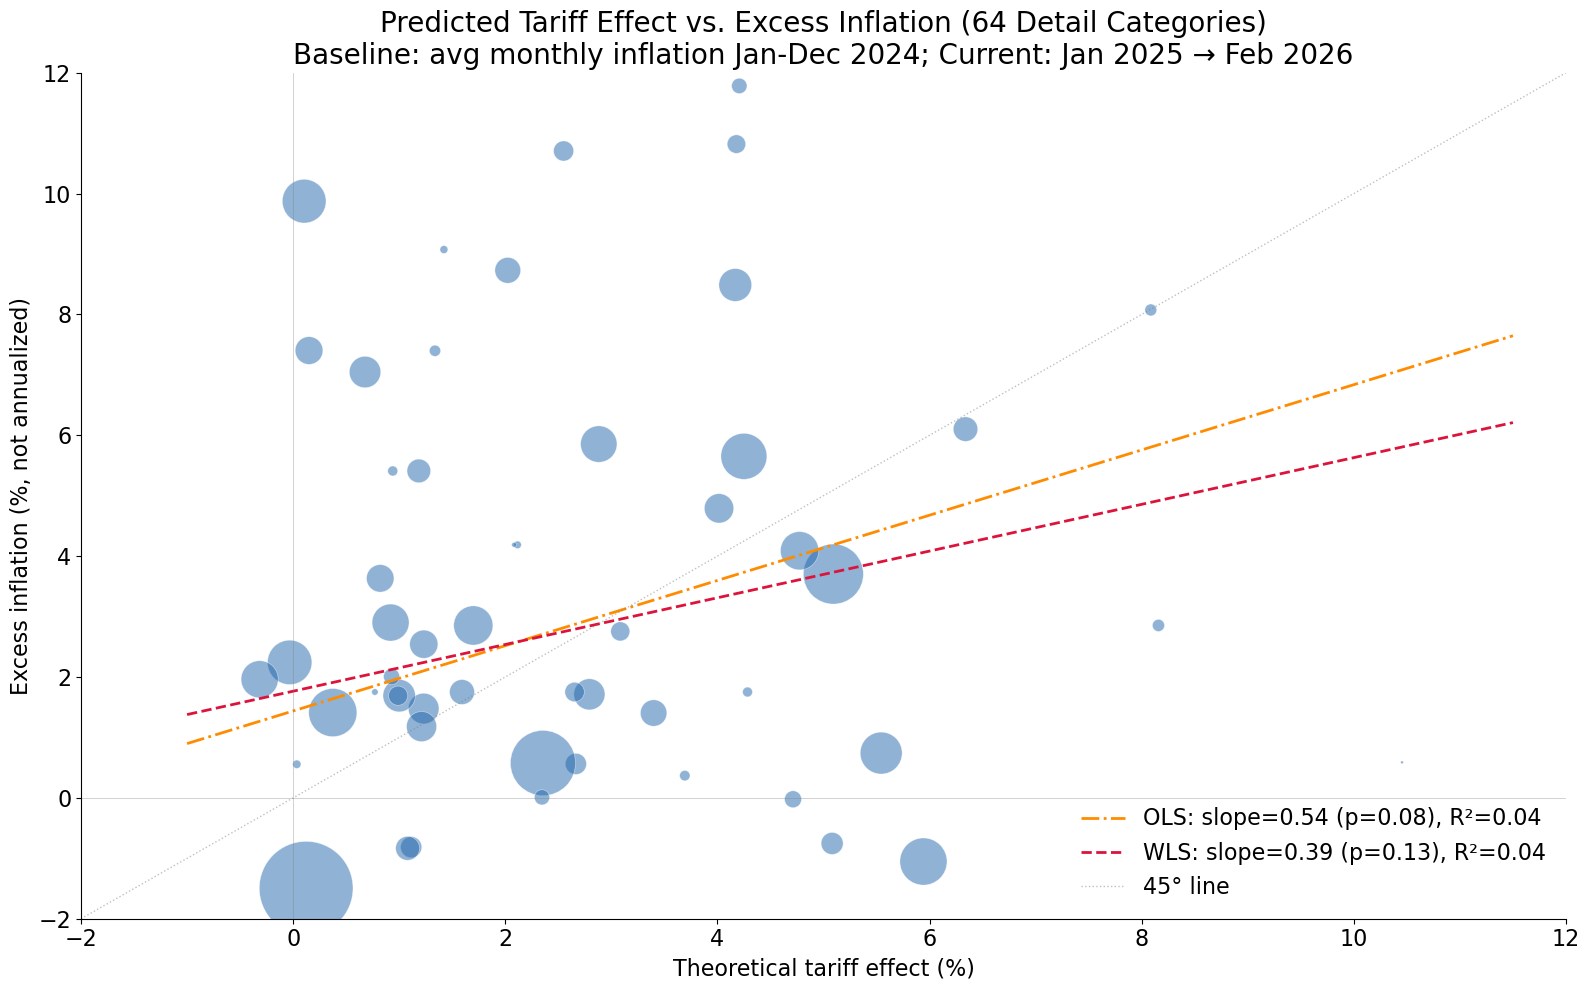


OLS: slope=0.54 (p=0.08), intercept=1.44, R²=0.040
WLS: slope=0.39 (p=0.13), intercept=1.77, R²=0.037

Fed Figure A3: slope=0.78, intercept=0.39
Our 27-cat:    slope=0.08, intercept=2.73, R²=0.001
Saved figures/fed_fig_a3_detail.png


In [107]:
# ── Scatter: Fed window (64 detail categories) ──────────────────────────────

fig, ax = plt.subplots(figsize=(16, 10))

x = results['predicted_effect'] * 100
y = results['excess_inflation'] * 100
sizes = results['pce_share'] * 30000

ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac', edgecolors='white', linewidths=0.5)

ols = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
slope_ols, intercept_ols = ols.params.iloc[1], ols.params.iloc[0]
p_slope_ols = ols.pvalues.iloc[1]

wls = sm.WLS(y, sm.add_constant(x), weights=results['pce_share']).fit()
slope_wls, intercept_wls = wls.params.iloc[1], wls.params.iloc[0]
p_slope_wls = wls.pvalues.iloc[1]

x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
ax.plot(x_grid, intercept_ols + slope_ols * x_grid,
        color='darkorange', linewidth=2, linestyle='-.',
        label=f'OLS: slope={slope_ols:.2f} (p={p_slope_ols:.2f}), R\u00b2={ols.rsquared:.2f}')

ax.plot(x_grid, intercept_wls + slope_wls * x_grid,
        color='crimson', linewidth=2, linestyle='--',
        label=f'WLS: slope={slope_wls:.2f} (p={p_slope_wls:.2f}), R\u00b2={wls.rsquared:.2f}')

lim = max(x.max(), y.max()) * 1.15
ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
        linestyle=':', alpha=0.5, label='45\u00b0 line')

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
ax.set_ylabel('Excess inflation (%, not annualized)', fontsize=16)
ax.set_title(
    f'Predicted Tariff Effect vs. Excess Inflation ({len(results)} Detail Categories)\n'
    'Baseline: avg monthly inflation Jan-Dec 2024; Current: Jan 2025 \u2192 Feb 2026',
    fontsize=20
)
ax.legend(fontsize=16, frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(-2, 12)
ax.set_ylim(-2, 12)

ax.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_detail.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nOLS: slope={slope_ols:.2f} (p={p_slope_ols:.2f}), '
      f'intercept={intercept_ols:.2f}, R\u00b2={ols.rsquared:.3f}')
print(f'WLS: slope={slope_wls:.2f} (p={p_slope_wls:.2f}), intercept={intercept_wls:.2f}, '
      f'R\u00b2={wls.rsquared:.3f}')
print(f'\nFed Figure A3: slope=0.78, intercept=0.39')
print(f'Our 27-cat:    slope=0.08, intercept=2.73, R\u00b2=0.001')
print('Saved figures/fed_fig_a3_detail.png')

In [108]:
# ── Summary: 27-category vs 64-category vs Fed ──────────────────────────────

print('=' * 72)
print('  Detail vs. Summary Comparison')
print('=' * 72)

print(f'\n  {"Metric":<35s} {"27-cat":>10s} {"64-cat":>10s} {"Fed":>10s}')
print(f'  {"-"*35} {"-"*10} {"-"*10} {"-"*10}')
print(f'  {"OLS slope":<35s} {"0.08":>10s} {slope_ols:>10.2f} {"0.78":>10s}')
print(f'  {"OLS intercept":<35s} {"2.73":>10s} {intercept_ols:>10.2f} {"0.39":>10s}')
print(f'  {"OLS R-squared":<35s} {"0.001":>10s} {ols.rsquared:>10.3f} {"n/a":>10s}')
print(f'  {"WLS slope":<35s} {"":>10s} {slope_wls:>10.2f} {"":>10s}')
print(f'  {"N categories":<35s} {"27":>10s} {len(results):>10d} {"~59":>10s}')
print(f'  {"Predicted total (pp)":<35s} {"2.08":>10s} '
      f'{results["predicted_contrib_pp"].sum():>10.2f} {"~3.1":>10s}')

print(f'\n  Key question: does finer granularity improve the slope/R\u00b2?')
if abs(slope_ols) > 0.2:
    print(f'  >> YES: slope improved from 0.08 to {slope_ols:.2f}')
else:
    print(f'  >> NO: slope still near zero ({slope_ols:.2f})')

  Detail vs. Summary Comparison

  Metric                                  27-cat     64-cat        Fed
  ----------------------------------- ---------- ---------- ----------
  OLS slope                                 0.08       0.54       0.78
  OLS intercept                             2.73       1.44       0.39
  OLS R-squared                            0.001      0.040        n/a
  WLS slope                                            0.39           
  N categories                                27         64        ~59
  Predicted total (pp)                      2.08       2.17       ~3.1

  Key question: does finer granularity improve the slope/R²?
  >> YES: slope improved from 0.08 to 0.54


## Pre-period and Window of Inflation (comparison document, Section 3)

Side-by-side: excess inflation (Fed baseline) vs. actual inflation at different start dates.

In [ ]:
# ── Side-by-side: Excess vs Actual inflation, Jan 2025 → Feb 2026 (64 cats) ──
# Left panel:  Excess inflation (Fed 2024 monthly baseline scaled to 13 mo)
# Right panel: Actual inflation (no baseline subtraction)

# Fed baseline: avg monthly rate 2024, scaled to 13 months
months_2024 = [f'2024-{m:02d}' for m in range(1, 13)]
months_2024_prev = ['2023-12'] + [f'2024-{m:02d}' for m in range(1, 12)]
monthly_rates_64 = pd.DataFrame(index=_price_wide.index)
for cur, prev in zip(months_2024, months_2024_prev):
    if cur in _price_wide.columns and prev in _price_wide.columns:
        monthly_rates_64[cur] = _price_wide[cur] / _price_wide[prev] - 1
avg_monthly_64 = monthly_rates_64.mean(axis=1)
baseline_13_64 = (1 + avg_monthly_64)**13 - 1

# Current: Jan 2025 -> Feb 2026
current_13_64 = _price_wide['2026-02'] / _price_wide['2025-01'] - 1
excess_13_64 = current_13_64 - baseline_13_64

panels = [
    ('Excess inflation (Fed baseline)', excess_13_64, 'Excess inflation (%, 13-month)'),
    ('Actual inflation (no baseline)', current_13_64, 'Actual inflation (%, 13-month)'),
]

fig, axes = plt.subplots(1, 2, figsize=(32, 12))

for ax, (panel_title, y_series, y_label) in zip(axes, panels):
    inf_df = pd.DataFrame({
        'y_val': y_series,
    }).reset_index().rename(columns={'index': 'PCE_category'})

    res = core[['PCE_category', 'predicted_effect', 'pce_share',
                'purchasers_value_total']].copy()
    res = res.merge(inf_df, on='PCE_category', how='inner')

    x = res['predicted_effect'] * 100
    y = res['y_val'] * 100
    sizes = res['pce_share'] * 30000

    ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac',
               edgecolors='white', linewidths=0.5)

    ols_fit = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
    sl_ols, int_ols = ols_fit.params.iloc[1], ols_fit.params.iloc[0]
    p_ols = ols_fit.pvalues.iloc[1]

    wls_fit = sm.WLS(y, sm.add_constant(x), weights=res['pce_share']).fit()
    sl_wls, int_wls = wls_fit.params.iloc[1], wls_fit.params.iloc[0]
    p_wls = wls_fit.pvalues.iloc[1]

    x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
    ax.plot(x_grid, int_ols + sl_ols * x_grid,
            color='darkorange', linewidth=2, linestyle='-.',
            label=f'OLS: slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.2f}')
    ax.plot(x_grid, int_wls + sl_wls * x_grid,
            color='crimson', linewidth=2, linestyle='--',
            label=f'WLS: slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.2f}')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
            linestyle=':', alpha=0.5, label='45\u00b0 line')

    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

    ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
    ax.set_ylabel(y_label, fontsize=16)
    ax.set_title(
        f'{panel_title}\n'
        f'Jan 2025 \u2192 Feb 2026 (13 months)  |  OLS slope={sl_ols:.2f} (p={p_ols:.2f})',
        fontsize=20
    )
    ax.legend(fontsize=16, frameon=False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlim(-2, 12)
    ax.set_ylim(-2, 12)
    ax.tick_params(axis='both', labelsize=16)

    print(f'{panel_title}: OLS slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.3f}  |  '
          f'WLS slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.3f}')

plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_detail_excess_vs_actual.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/fed_fig_a3_detail_excess_vs_actual.png')

In [ ]:
# ── Side-by-side: Excess vs Actual, Dec 2024 → Feb 2026 (64 cats) ──────
# Left panel:  Excess inflation (Fed 2024 monthly baseline scaled to 14 mo)
# Right panel: Actual inflation (no baseline subtraction)

# Fed baseline: avg monthly rate 2024, scaled to 14 months
months_2024 = [f'2024-{m:02d}' for m in range(1, 13)]
months_2024_prev = ['2023-12'] + [f'2024-{m:02d}' for m in range(1, 12)]
monthly_rates_64 = pd.DataFrame(index=_price_wide.index)
for cur, prev in zip(months_2024, months_2024_prev):
    if cur in _price_wide.columns and prev in _price_wide.columns:
        monthly_rates_64[cur] = _price_wide[cur] / _price_wide[prev] - 1
avg_monthly_64 = monthly_rates_64.mean(axis=1)
baseline_scaled_64 = (1 + avg_monthly_64)**14 - 1

current_64 = _price_wide['2026-02'] / _price_wide['2024-12'] - 1
excess_64 = current_64 - baseline_scaled_64

panels = [
    ('Excess inflation (Fed baseline)', excess_64, 'Excess inflation (%, 14-month)'),
    ('Actual inflation (no baseline)', current_64, 'Actual inflation (%, 14-month)'),
]

fig, axes = plt.subplots(1, 2, figsize=(32, 12))

for ax, (panel_title, y_series, y_label) in zip(axes, panels):
    inf_df = pd.DataFrame({
        'y_val': y_series,
    }).reset_index().rename(columns={'index': 'PCE_category'})

    res = core[['PCE_category', 'predicted_effect', 'pce_share',
                'purchasers_value_total']].copy()
    res = res.merge(inf_df, on='PCE_category', how='inner')

    x = res['predicted_effect'] * 100
    y = res['y_val'] * 100
    sizes = res['pce_share'] * 30000

    ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac',
               edgecolors='white', linewidths=0.5)

    ols_fit = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
    sl_ols, int_ols = ols_fit.params.iloc[1], ols_fit.params.iloc[0]
    p_ols = ols_fit.pvalues.iloc[1]

    wls_fit = sm.WLS(y, sm.add_constant(x), weights=res['pce_share']).fit()
    sl_wls, int_wls = wls_fit.params.iloc[1], wls_fit.params.iloc[0]
    p_wls = wls_fit.pvalues.iloc[1]

    x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
    ax.plot(x_grid, int_ols + sl_ols * x_grid,
            color='darkorange', linewidth=2, linestyle='-.',
            label=f'OLS: slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.2f}')
    ax.plot(x_grid, int_wls + sl_wls * x_grid,
            color='crimson', linewidth=2, linestyle='--',
            label=f'WLS: slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.2f}')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
            linestyle=':', alpha=0.5, label='45\u00b0 line')

    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

    ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
    ax.set_ylabel(y_label, fontsize=16)
    ax.set_title(
        f'{panel_title}\n'
        f'Dec 2024 \u2192 Feb 2026 (14 months)  |  OLS slope={sl_ols:.2f} (p={p_ols:.2f})',
        fontsize=20
    )
    ax.legend(fontsize=16, frameon=False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlim(-2, 12)
    ax.set_ylim(-2, 12)
    ax.tick_params(axis='both', labelsize=16)

    print(f'{panel_title}: OLS slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.3f}  |  '
          f'WLS slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.3f}')

plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_detail_excess_vs_actual_dec24.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/fed_fig_a3_detail_excess_vs_actual_dec24.png')

## Additional Analysis

Supporting figures not directly referenced in the comparison document.

Categories matched: 64
Median baseline (annual): -0.01%
Median baseline (13-mo scaled): -0.01%
Median excess inflation: 3.62%


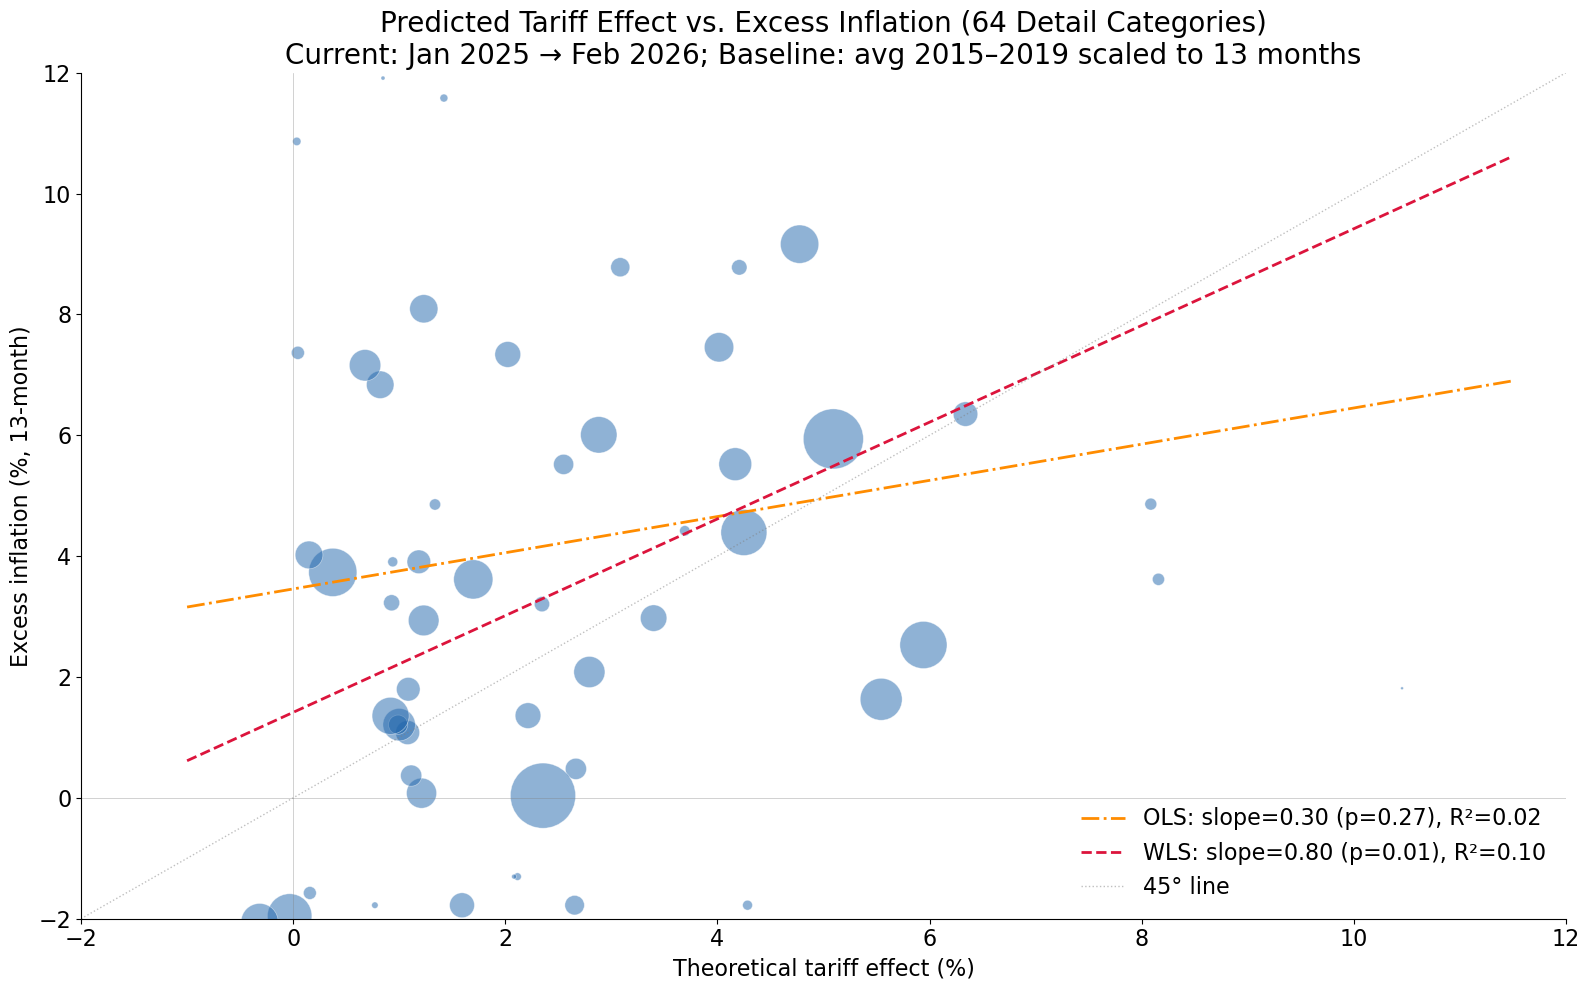


OLS: slope=0.30 (p=0.27), intercept=3.46, R²=0.016
WLS: slope=0.80 (p=0.01), intercept=1.41, R²=0.101
Saved figures/fed_fig_a3_detail_repo_window.png


In [109]:
# ── Excess inflation: Jan 2025 → Feb 2026, baseline 2015-2019 (64 categories) ─
# Current:  P(2026-02) / P(2025-01) - 1  (13 months)
# Baseline: avg Dec-over-Dec growth rate 2015-2019, scaled to 13 months

baseline_years = range(2015, 2020)
baseline_rates = pd.DataFrame(index=_price_wide.index)

for yr in baseline_years:
    dec_cur = f'{yr}-12'
    dec_prev = f'{yr-1}-12'
    if dec_cur in _price_wide.columns and dec_prev in _price_wide.columns:
        baseline_rates[yr] = _price_wide[dec_cur] / _price_wide[dec_prev] - 1
    else:
        print(f'  WARNING: missing {dec_prev} or {dec_cur}')

baseline_avg = baseline_rates.mean(axis=1)

# Scale annual baseline to 13 months
N_MONTHS_REPO = 13
baseline_scaled_13 = (1 + baseline_avg)**(N_MONTHS_REPO / 12) - 1

# Current period: Jan 2025 -> Feb 2026 (13 months)
current_inf_repo = _price_wide['2026-02'] / _price_wide['2025-01'] - 1
excess_inf_repo = current_inf_repo - baseline_scaled_13

# Merge
inflation_repo_df = pd.DataFrame({
    'current_inflation': current_inf_repo,
    'baseline_avg': baseline_avg,
    'baseline_scaled_13mo': baseline_scaled_13,
    'excess_inflation': excess_inf_repo,
}).reset_index().rename(columns={'index': 'PCE_category'})

results_repo = core[['PCE_category', 'predicted_effect', 'pce_share',
                      'purchasers_value_total']].copy()
results_repo = results_repo.merge(inflation_repo_df, on='PCE_category', how='inner')

print(f'Categories matched: {len(results_repo)}')
print(f'Median baseline (annual): {baseline_avg.median():.2%}')
print(f'Median baseline (13-mo scaled): {baseline_scaled_13.median():.2%}')
print(f'Median excess inflation: {excess_inf_repo.median():.2%}')

# ── Scatter ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))

x = results_repo['predicted_effect'] * 100
y = results_repo['excess_inflation'] * 100
sizes = results_repo['pce_share'] * 30000

ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac', edgecolors='white', linewidths=0.5)

ols_r = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
slope_ols_r, intercept_ols_r = ols_r.params.iloc[1], ols_r.params.iloc[0]
p_slope_ols_r = ols_r.pvalues.iloc[1]

wls_r = sm.WLS(y, sm.add_constant(x), weights=results_repo['pce_share']).fit()
slope_wls_r, intercept_wls_r = wls_r.params.iloc[1], wls_r.params.iloc[0]
p_slope_wls_r = wls_r.pvalues.iloc[1]

x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
ax.plot(x_grid, intercept_ols_r + slope_ols_r * x_grid,
        color='darkorange', linewidth=2, linestyle='-.',
        label=f'OLS: slope={slope_ols_r:.2f} (p={p_slope_ols_r:.2f}), R\u00b2={ols_r.rsquared:.2f}')
ax.plot(x_grid, intercept_wls_r + slope_wls_r * x_grid,
        color='crimson', linewidth=2, linestyle='--',
        label=f'WLS: slope={slope_wls_r:.2f} (p={p_slope_wls_r:.2f}), R\u00b2={wls_r.rsquared:.2f}')

lim = max(x.max(), y.max()) * 1.15
ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
        linestyle=':', alpha=0.5, label='45\u00b0 line')

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
ax.set_ylabel('Excess inflation (%, 13-month)', fontsize=16)
ax.set_title(
    f'Predicted Tariff Effect vs. Excess Inflation ({len(results_repo)} Detail Categories)\n'
    'Current: Jan 2025 \u2192 Feb 2026; Baseline: avg 2015\u20132019 scaled to 13 months',
    fontsize=20
)
ax.legend(fontsize=16, frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(-2, 12)
ax.set_ylim(-2, 12)

ax.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_detail_repo_window.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nOLS: slope={slope_ols_r:.2f} (p={p_slope_ols_r:.2f}), '
      f'intercept={intercept_ols_r:.2f}, R\u00b2={ols_r.rsquared:.3f}')
print(f'WLS: slope={slope_wls_r:.2f} (p={p_slope_wls_r:.2f}), intercept={intercept_wls_r:.2f}, '
      f'R\u00b2={wls_r.rsquared:.3f}')
print('Saved figures/fed_fig_a3_detail_repo_window.png')

Categories matched: 64
Median excess inflation (14mo): 3.53%


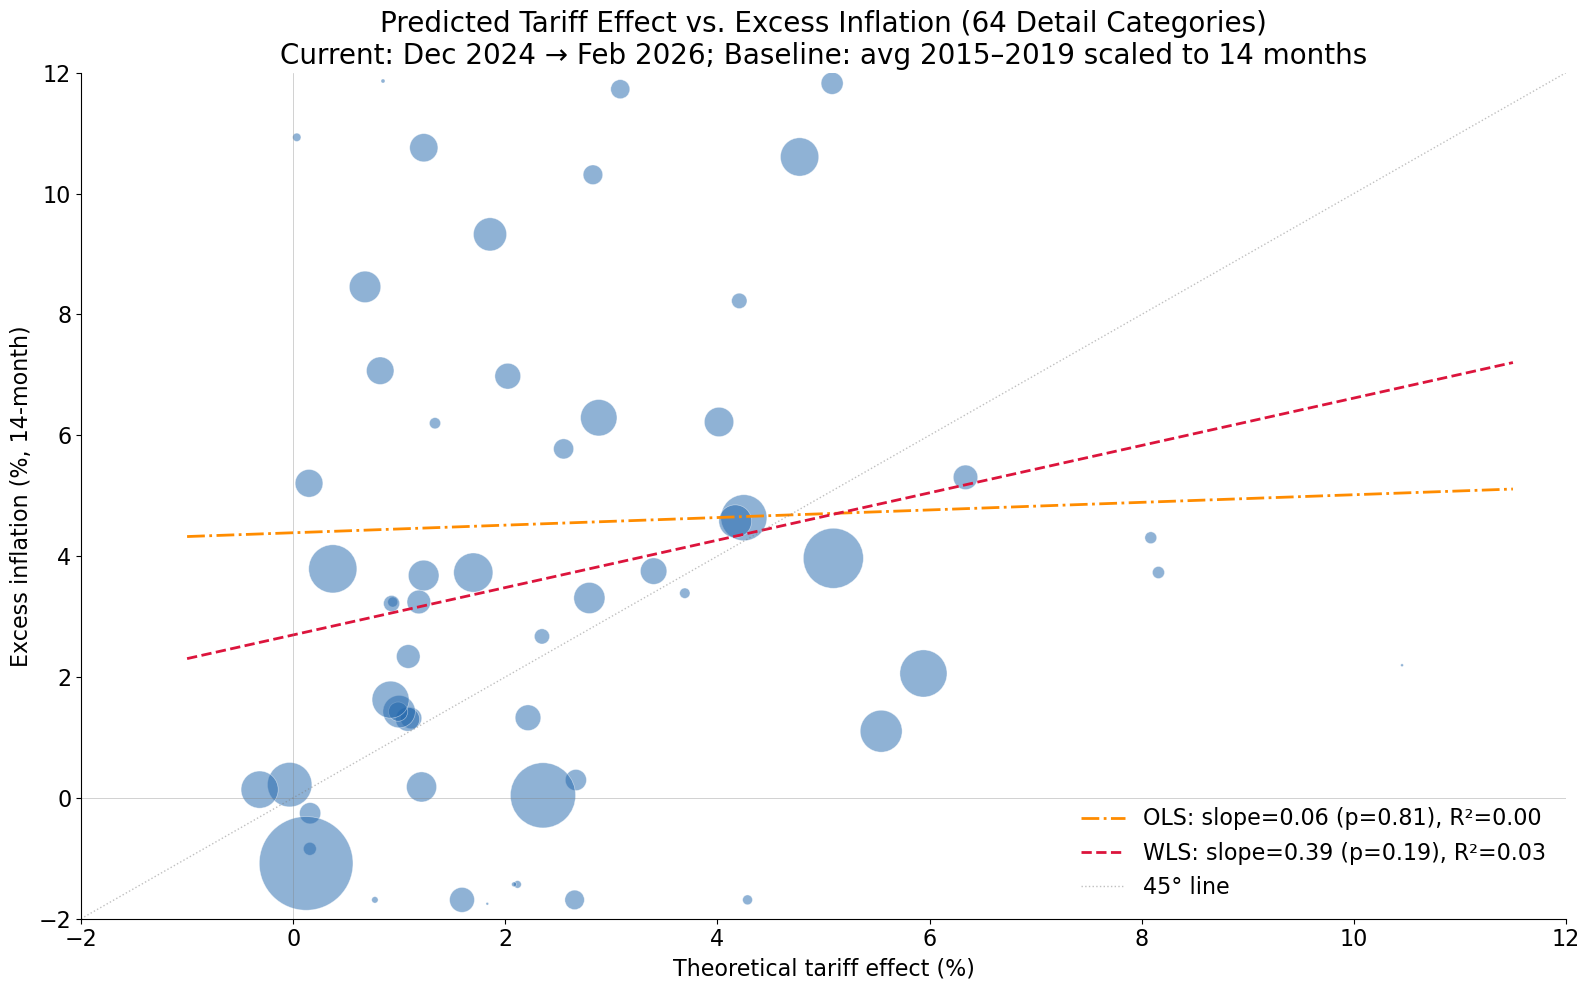


OLS: slope=0.06 (p=0.81), intercept=4.39, R²=0.001
WLS: slope=0.39 (p=0.19), intercept=2.70, R²=0.028
Saved figures/fed_fig_a3_detail_extended.png


In [110]:
# ── Excess inflation: Dec 2024 -> Feb 2026 vs 2015-2019 baseline ─────────────
# Current:  P(2026-02) / P(2024-12) - 1   (14 months)
# Baseline: avg annual Dec-over-Dec rate (2015-2019), scaled to 14 months
#   baseline_14mo = (1 + annual_rate)^(14/12) - 1

N_MONTHS_EXT = 14
baseline_scaled_14 = (1 + baseline_avg)**(N_MONTHS_EXT / 12) - 1

current_inf_ext = _price_wide['2026-02'] / _price_wide['2024-12'] - 1
excess_inf_ext = current_inf_ext - baseline_scaled_14

# Merge
inflation_ext_df = pd.DataFrame({
    'current_inflation': current_inf_ext,
    'baseline_scaled': baseline_scaled_14,
    'excess_inflation': excess_inf_ext,
}).reset_index().rename(columns={'index': 'PCE_category'})

results_ext = core[['PCE_category', 'predicted_effect', 'pce_share',
                     'purchasers_value_total']].copy()
results_ext = results_ext.merge(inflation_ext_df, on='PCE_category', how='inner')

print(f'Categories matched: {len(results_ext)}')
print(f'Median excess inflation (14mo): {excess_inf_ext.median():.2%}')

# ── Scatter ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))

x = results_ext['predicted_effect'] * 100
y = results_ext['excess_inflation'] * 100
sizes = results_ext['pce_share'] * 30000

ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac', edgecolors='white', linewidths=0.5)

ols_e = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
slope_ols_e, intercept_ols_e = ols_e.params.iloc[1], ols_e.params.iloc[0]
p_slope_ols_e = ols_e.pvalues.iloc[1]

wls_e = sm.WLS(y, sm.add_constant(x), weights=results_ext['pce_share']).fit()
slope_wls_e, intercept_wls_e = wls_e.params.iloc[1], wls_e.params.iloc[0]
p_slope_wls_e = wls_e.pvalues.iloc[1]

x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
ax.plot(x_grid, intercept_ols_e + slope_ols_e * x_grid,
        color='darkorange', linewidth=2, linestyle='-.',
        label=f'OLS: slope={slope_ols_e:.2f} (p={p_slope_ols_e:.2f}), R\u00b2={ols_e.rsquared:.2f}')
ax.plot(x_grid, intercept_wls_e + slope_wls_e * x_grid,
        color='crimson', linewidth=2, linestyle='--',
        label=f'WLS: slope={slope_wls_e:.2f} (p={p_slope_wls_e:.2f}), R\u00b2={wls_e.rsquared:.2f}')

lim = max(x.max(), y.max()) * 1.15
ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
        linestyle=':', alpha=0.5, label='45\u00b0 line')

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
ax.set_ylabel('Excess inflation (%, 14-month)', fontsize=16)
ax.set_title(
    f'Predicted Tariff Effect vs. Excess Inflation ({len(results_ext)} Detail Categories)\n'
    'Current: Dec 2024 \u2192 Feb 2026; Baseline: avg 2015\u20132019 scaled to 14 months',
    fontsize=20
)
ax.legend(fontsize=16, frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(-2, 12)
ax.set_ylim(-2, 12)

ax.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_detail_extended.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nOLS: slope={slope_ols_e:.2f} (p={p_slope_ols_e:.2f}), '
      f'intercept={intercept_ols_e:.2f}, R\u00b2={ols_e.rsquared:.3f}')
print(f'WLS: slope={slope_wls_e:.2f} (p={p_slope_wls_e:.2f}), intercept={intercept_wls_e:.2f}, '
      f'R\u00b2={wls_e.rsquared:.3f}')
print('Saved figures/fed_fig_a3_detail_extended.png')

Categories matched: 64
Median actual inflation: 3.02%


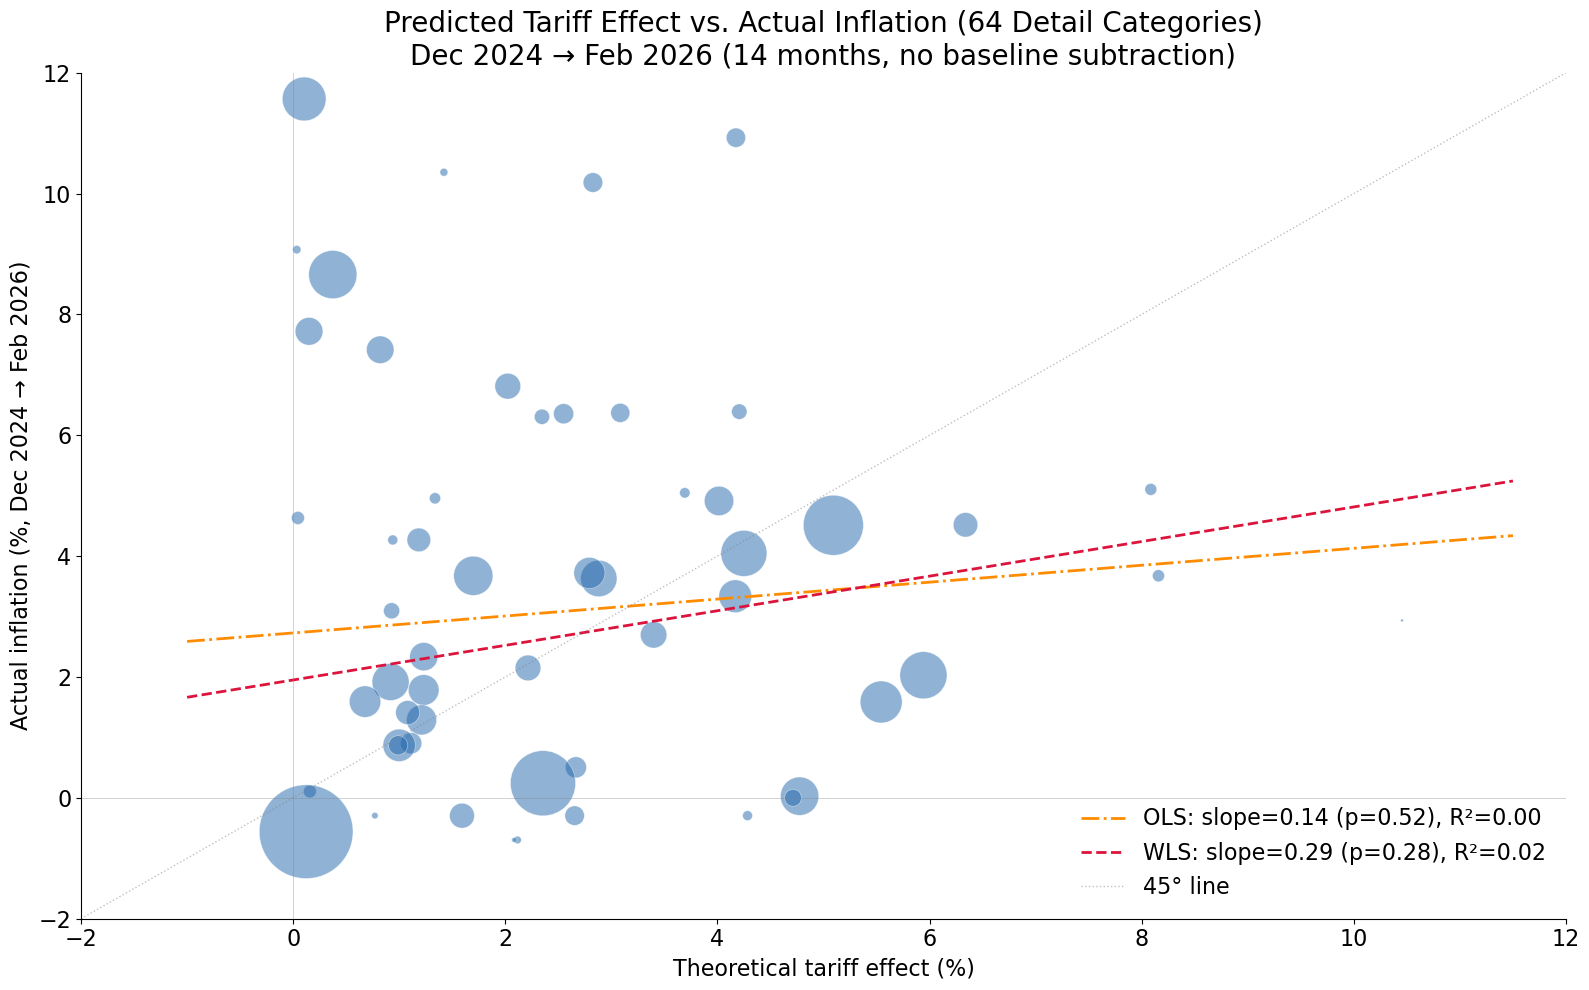


OLS: slope=0.14 (p=0.52), intercept=2.73, R²=0.004
WLS: slope=0.29 (p=0.28), intercept=1.95, R²=0.019
Saved figures/fed_fig_a3_detail_actual_inflation.png


In [111]:
# ── Actual inflation: Dec 2024 -> Feb 2026 (64 categories, no baseline) ──────
# Y = P(2026-02) / P(2024-12) - 1

actual_inf_64 = _price_wide['2026-02'] / _price_wide['2025-01'] - 1

#actual_inf_64 = _price_wide['2026-02'] / _price_wide['2025-01'] - 1

actual_inf_df = pd.DataFrame({
    'actual_inflation': actual_inf_64,
}).reset_index().rename(columns={'index': 'PCE_category'})

results_actual = core[['PCE_category', 'predicted_effect', 'pce_share',
                       'purchasers_value_total']].copy()
results_actual = results_actual.merge(actual_inf_df, on='PCE_category', how='inner')

print(f'Categories matched: {len(results_actual)}')
print(f'Median actual inflation: {actual_inf_64.median():.2%}')

# ── Scatter ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))

x = results_actual['predicted_effect'] * 100
y = results_actual['actual_inflation'] * 100
sizes = results_actual['pce_share'] * 30000

ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac', edgecolors='white', linewidths=0.5)

ols_a = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
slope_ols_a, intercept_ols_a = ols_a.params.iloc[1], ols_a.params.iloc[0]
p_slope_ols_a = ols_a.pvalues.iloc[1]

wls_a = sm.WLS(y, sm.add_constant(x), weights=results_actual['pce_share']).fit()
slope_wls_a, intercept_wls_a = wls_a.params.iloc[1], wls_a.params.iloc[0]
p_slope_wls_a = wls_a.pvalues.iloc[1]

x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
ax.plot(x_grid, intercept_ols_a + slope_ols_a * x_grid,
        color='darkorange', linewidth=2, linestyle='-.',
        label=f'OLS: slope={slope_ols_a:.2f} (p={p_slope_ols_a:.2f}), R\u00b2={ols_a.rsquared:.2f}')
ax.plot(x_grid, intercept_wls_a + slope_wls_a * x_grid,
        color='crimson', linewidth=2, linestyle='--',
        label=f'WLS: slope={slope_wls_a:.2f} (p={p_slope_wls_a:.2f}), R\u00b2={wls_a.rsquared:.2f}')

lim = max(x.max(), y.max()) * 1.15
ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
        linestyle=':', alpha=0.5, label='45\u00b0 line')

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
ax.set_ylabel('Actual inflation (%, Dec 2024 \u2192 Feb 2026)', fontsize=16)
ax.set_title(
    f'Predicted Tariff Effect vs. Actual Inflation ({len(results_actual)} Detail Categories)\n'
    'Dec 2024 \u2192 Feb 2026 (14 months, no baseline subtraction)',
    fontsize=20
)
ax.legend(fontsize=16, frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(-2, 12)
ax.set_ylim(-2, 12)

ax.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_detail_actual_inflation.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nOLS: slope={slope_ols_a:.2f} (p={p_slope_ols_a:.2f}), '
      f'intercept={intercept_ols_a:.2f}, R\u00b2={ols_a.rsquared:.3f}')
print(f'WLS: slope={slope_wls_a:.2f} (p={p_slope_wls_a:.2f}), intercept={intercept_wls_a:.2f}, '
      f'R\u00b2={wls_a.rsquared:.3f}')
print('Saved figures/fed_fig_a3_detail_actual_inflation.png')

In [112]:
# ── Start-month sensitivity: Dec 2024 vs Jan 2025 ────────────────────────────
# Same endpoint (Feb 2026), same baseline (Fed's 2024 monthly avg)
# Only difference: denominator is P(2024-12) vs P(2025-01)

print('Start-month sensitivity test (Fed baseline, endpoint Feb 2026)')
print('=' * 65)

x_pred = core.set_index('PCE_category')['predicted_effect']

for start_label, start_month, n_months in [
    ('Dec 2024', '2024-12', 14),
    ('Jan 2025', '2025-01', 13),
    ('Feb 2025', '2025-02', 12),
    ('Mar 2025', '2025-03', 11),
    ('Mar 2025', '2025-03', 11),
    ('Apr 2025', '2025-04', 10),
    ('May 2025', '2025-05', 9),
    ('Jun 2025', '2025-06', 8),
    ('Jul 2025', '2025-07', 7),
    ('Aug 2025', '2025-08', 6),
    ('Sep 2025', '2025-09', 5),
    ('Oct 2025', '2025-10', 4),

]:
    current = _price_wide['2026-02'] / _price_wide[start_month] - 1
    baseline_scaled = (1 + avg_monthly_rate)**n_months - 1
    excess = current - baseline_scaled

    # Merge with predicted effect
    merged = pd.DataFrame({
        'predicted_effect': x_pred,
        'excess_inflation': excess,
    }).dropna()

    x = merged['predicted_effect'] * 100
    y = merged['excess_inflation'] * 100

    ols_test = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
    s = ols_test.params.iloc[1]
    p = ols_test.pvalues.iloc[1]
    r2 = ols_test.rsquared
    icpt = ols_test.params.iloc[0]

    print(f'  Start={start_label} ({n_months}mo):  '
          f'slope={s:.3f} (p={p:.3f}), intercept={icpt:.2f}, R\u00b2={r2:.4f}')

print(f'\n  Fed reported:           slope=0.780 (p=0.040)')

Start-month sensitivity test (Fed baseline, endpoint Feb 2026)
  Start=Dec 2024 (14mo):  slope=0.327 (p=0.268), intercept=2.19, R²=0.0144
  Start=Jan 2025 (13mo):  slope=0.540 (p=0.084), intercept=1.44, R²=0.0396
  Start=Feb 2025 (12mo):  slope=0.542 (p=0.071), intercept=1.42, R²=0.0475
  Start=Mar 2025 (11mo):  slope=0.543 (p=0.061), intercept=1.62, R²=0.0508
  Start=Mar 2025 (11mo):  slope=0.543 (p=0.061), intercept=1.62, R²=0.0508
  Start=Apr 2025 (10mo):  slope=0.459 (p=0.064), intercept=1.71, R²=0.0431
  Start=May 2025 (9mo):  slope=0.385 (p=0.089), intercept=2.11, R²=0.0271
  Start=Jun 2025 (8mo):  slope=0.189 (p=0.292), intercept=2.08, R²=0.0060
  Start=Jul 2025 (7mo):  slope=0.143 (p=0.347), intercept=1.80, R²=0.0047
  Start=Aug 2025 (6mo):  slope=0.217 (p=0.220), intercept=1.08, R²=0.0140
  Start=Sep 2025 (5mo):  slope=0.086 (p=0.611), intercept=1.11, R²=0.0025
  Start=Oct 2025 (4mo):  slope=0.098 (p=0.549), intercept=1.11, R²=0.0036

  Fed reported:           slope=0.780 (p=0

Dec 2024: OLS slope=-0.11 (p=0.63), R²=0.002  |  WLS slope=-0.16 (p=0.51), R²=0.007
Jan 2025: OLS slope=0.14 (p=0.52), R²=0.004  |  WLS slope=0.29 (p=0.28), R²=0.019


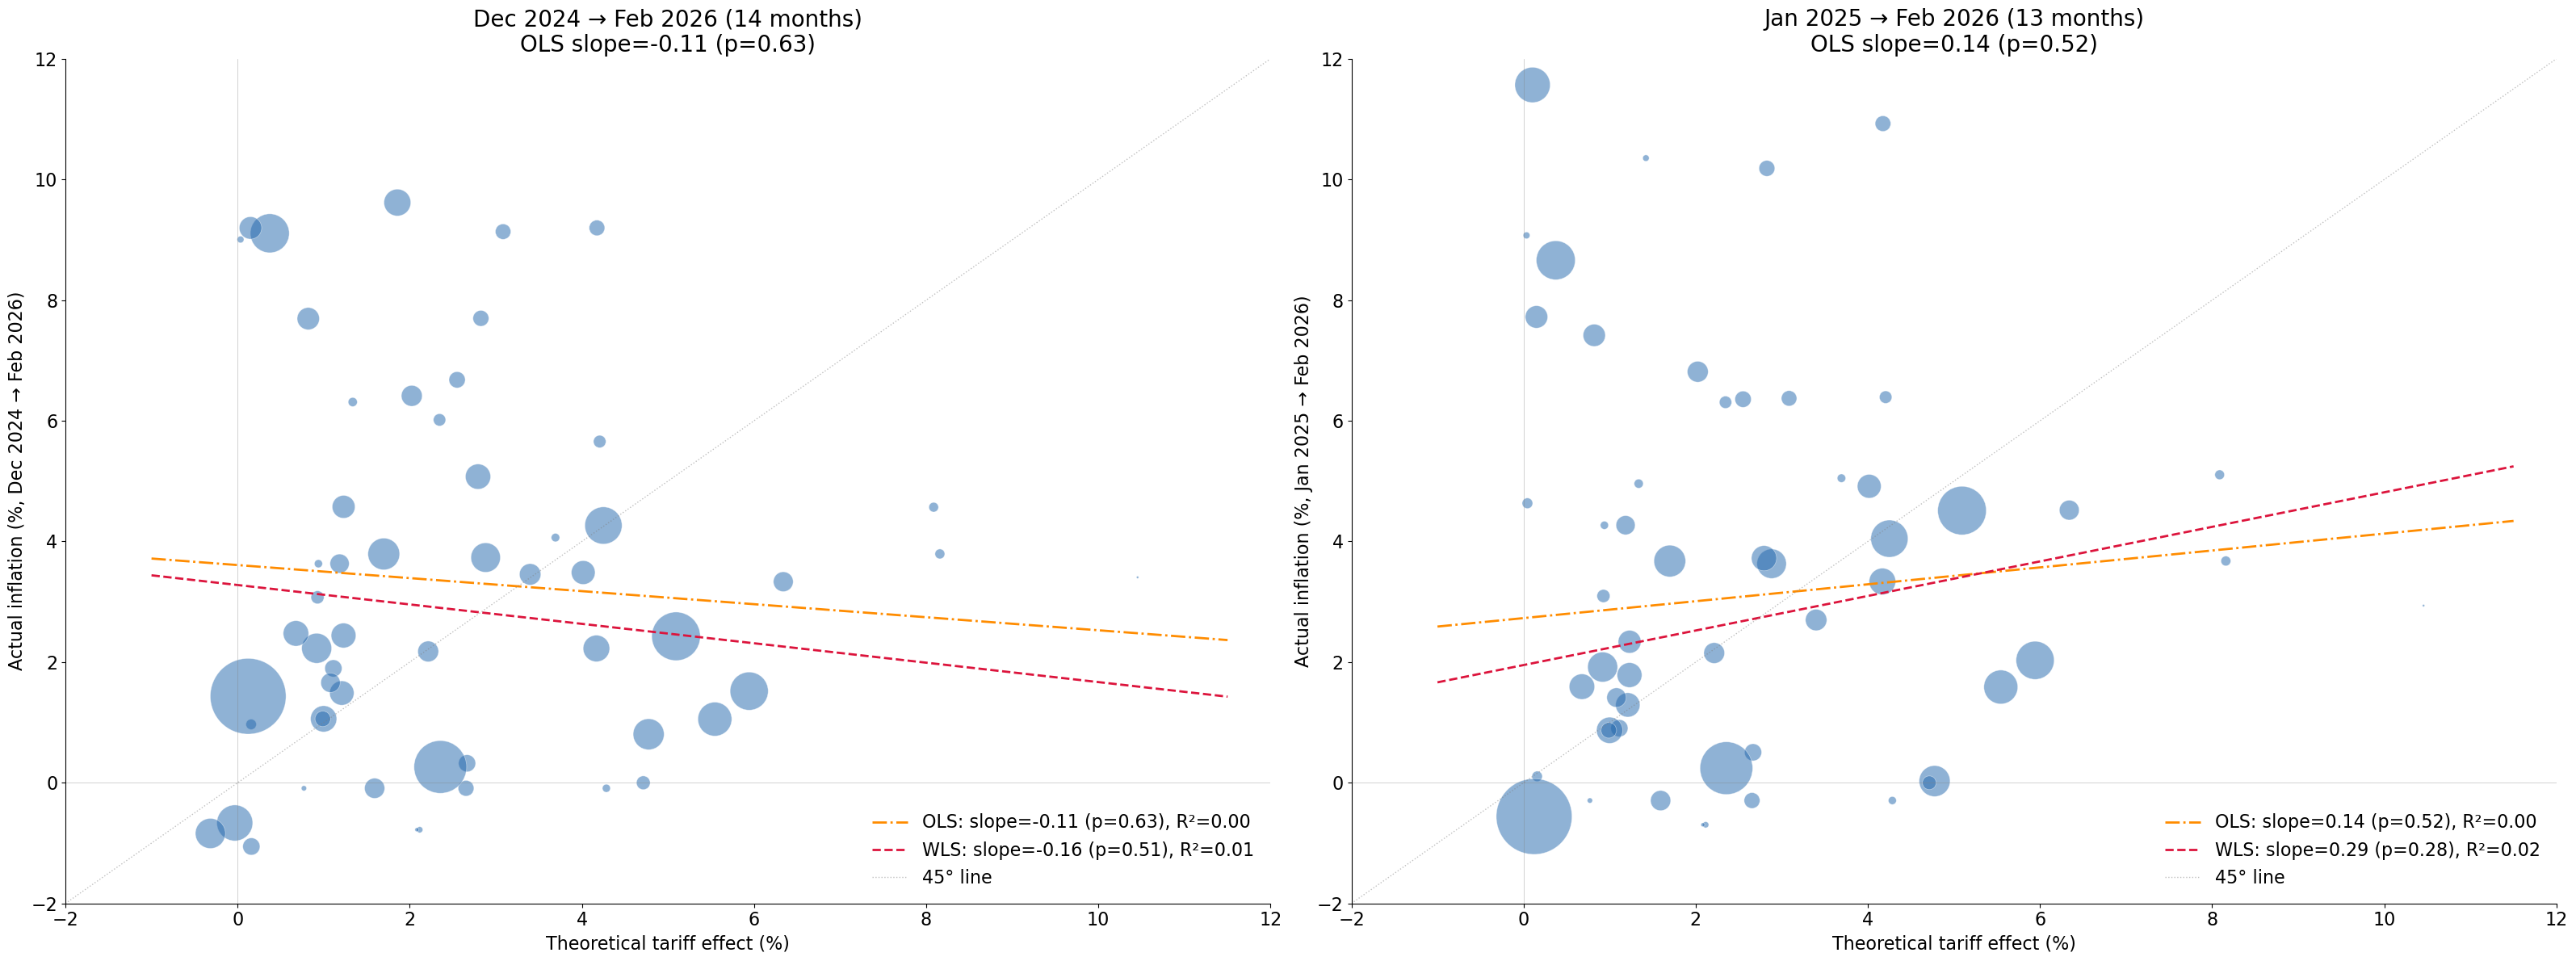

Saved figures/fed_fig_a3_detail_start_month_sidebyside.png


In [113]:
# ── Side-by-side: Actual inflation Dec 2024 vs Jan 2025 start (64 categories) ─
# Left panel:  P(2026-02) / P(2024-12) - 1  (14 months)
# Right panel: P(2026-02) / P(2025-01) - 1  (13 months)

panels = [
    ('Dec 2024', '2024-12', 14),
    ('Jan 2025', '2025-01', 13),
]

fig, axes = plt.subplots(1, 2, figsize=(32, 12))

for ax, (start_label, start_month, n_months) in zip(axes, panels):
    actual_inf = _price_wide['2026-02'] / _price_wide[start_month] - 1

    actual_inf_df = pd.DataFrame({
        'actual_inflation': actual_inf,
    }).reset_index().rename(columns={'index': 'PCE_category'})

    res = core[['PCE_category', 'predicted_effect', 'pce_share',
                'purchasers_value_total']].copy()
    res = res.merge(actual_inf_df, on='PCE_category', how='inner')

    x = res['predicted_effect'] * 100
    y = res['actual_inflation'] * 100
    sizes = res['pce_share'] * 30000

    ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac',
               edgecolors='white', linewidths=0.5)

    ols_fit = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
    sl_ols, int_ols = ols_fit.params.iloc[1], ols_fit.params.iloc[0]
    p_ols = ols_fit.pvalues.iloc[1]

    wls_fit = sm.WLS(y, sm.add_constant(x), weights=res['pce_share']).fit()
    sl_wls, int_wls = wls_fit.params.iloc[1], wls_fit.params.iloc[0]
    p_wls = wls_fit.pvalues.iloc[1]

    x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
    ax.plot(x_grid, int_ols + sl_ols * x_grid,
            color='darkorange', linewidth=2, linestyle='-.',
            label=f'OLS: slope={sl_ols:.2f} (p={p_ols:.2f}), R²={ols_fit.rsquared:.2f}')
    ax.plot(x_grid, int_wls + sl_wls * x_grid,
            color='crimson', linewidth=2, linestyle='--',
            label=f'WLS: slope={sl_wls:.2f} (p={p_wls:.2f}), R²={wls_fit.rsquared:.2f}')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
            linestyle=':', alpha=0.5, label='45° line')

    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

    ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
    ax.set_ylabel(f'Actual inflation (%, {start_label} → Feb 2026)', fontsize=16)
    ax.set_title(
        f'{start_label} → Feb 2026 ({n_months} months)\n'
        f'OLS slope={sl_ols:.2f} (p={p_ols:.2f})',
        fontsize=20
    )
    ax.legend(fontsize=16, frameon=False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlim(-2, 12)
    ax.set_ylim(-2, 12)
    ax.tick_params(axis='both', labelsize=16)

    print(f'{start_label}: OLS slope={sl_ols:.2f} (p={p_ols:.2f}), R²={ols_fit.rsquared:.3f}  |  '
          f'WLS slope={sl_wls:.2f} (p={p_wls:.2f}), R²={wls_fit.rsquared:.3f}')

plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_detail_start_month_sidebyside.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/fed_fig_a3_detail_start_month_sidebyside.png')

In [ ]:
# ── Side-by-side: Excess vs Actual, Apr 2025 → Feb 2026 (64 cats) ──────
# Left panel:  Excess inflation (Fed 2024 monthly baseline scaled to 10 mo)
# Right panel: Actual inflation (no baseline subtraction)

# Fed baseline: avg monthly rate 2024, scaled to 10 months
months_2024 = [f'2024-{m:02d}' for m in range(1, 13)]
months_2024_prev = ['2023-12'] + [f'2024-{m:02d}' for m in range(1, 12)]
monthly_rates_64 = pd.DataFrame(index=_price_wide.index)
for cur, prev in zip(months_2024, months_2024_prev):
    if cur in _price_wide.columns and prev in _price_wide.columns:
        monthly_rates_64[cur] = _price_wide[cur] / _price_wide[prev] - 1
avg_monthly_64 = monthly_rates_64.mean(axis=1)
baseline_scaled_64 = (1 + avg_monthly_64)**10 - 1

current_64 = _price_wide['2026-02'] / _price_wide['2025-04'] - 1
excess_64 = current_64 - baseline_scaled_64

panels = [
    ('Excess inflation (Fed baseline)', excess_64, 'Excess inflation (%, 10-month)'),
    ('Actual inflation (no baseline)', current_64, 'Actual inflation (%, 10-month)'),
]

fig, axes = plt.subplots(1, 2, figsize=(32, 12))

for ax, (panel_title, y_series, y_label) in zip(axes, panels):
    inf_df = pd.DataFrame({
        'y_val': y_series,
    }).reset_index().rename(columns={'index': 'PCE_category'})

    res = core[['PCE_category', 'predicted_effect', 'pce_share',
                'purchasers_value_total']].copy()
    res = res.merge(inf_df, on='PCE_category', how='inner')

    x = res['predicted_effect'] * 100
    y = res['y_val'] * 100
    sizes = res['pce_share'] * 30000

    ax.scatter(x, y, s=sizes, alpha=0.5, color='#2166ac',
               edgecolors='white', linewidths=0.5)

    ols_fit = sm.OLS(y, sm.add_constant(x)).fit(cov_type='HC1')
    sl_ols, int_ols = ols_fit.params.iloc[1], ols_fit.params.iloc[0]
    p_ols = ols_fit.pvalues.iloc[1]

    wls_fit = sm.WLS(y, sm.add_constant(x), weights=res['pce_share']).fit()
    sl_wls, int_wls = wls_fit.params.iloc[1], wls_fit.params.iloc[0]
    p_wls = wls_fit.pvalues.iloc[1]

    x_grid = np.linspace(-1, max(x.max(), 8) * 1.1, 100)
    ax.plot(x_grid, int_ols + sl_ols * x_grid,
            color='darkorange', linewidth=2, linestyle='-.',
            label=f'OLS: slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.2f}')
    ax.plot(x_grid, int_wls + sl_wls * x_grid,
            color='crimson', linewidth=2, linestyle='--',
            label=f'WLS: slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.2f}')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([-2, lim], [-2, lim], color='gray', linewidth=1,
            linestyle=':', alpha=0.5, label='45\u00b0 line')

    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

    ax.set_xlabel('Theoretical tariff effect (%)', fontsize=16)
    ax.set_ylabel(y_label, fontsize=16)
    ax.set_title(
        f'{panel_title}\n'
        f'Apr 2025 \u2192 Feb 2026 (10 months)  |  OLS slope={sl_ols:.2f} (p={p_ols:.2f})',
        fontsize=20
    )
    ax.legend(fontsize=16, frameon=False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlim(-2, 12)
    ax.set_ylim(-2, 12)
    ax.tick_params(axis='both', labelsize=16)

    print(f'{panel_title}: OLS slope={sl_ols:.2f} (p={p_ols:.2f}), R\u00b2={ols_fit.rsquared:.3f}  |  '
          f'WLS slope={sl_wls:.2f} (p={p_wls:.2f}), R\u00b2={wls_fit.rsquared:.3f}')

plt.tight_layout()
plt.savefig('../figures/fed_fig_a3_detail_excess_vs_actual_apr25.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/fed_fig_a3_detail_excess_vs_actual_apr25.png')